# 01 - Data Ingestion and Exploratory Data Analysis

This notebook handles the loading and cleaning of Inside Airbnb data for Sicilian cities, with comprehensive exploratory data analysis.

## Configuration


In [ ]:
# Configuration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FEATURES_DIR = PROJECT_ROOT / "features"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create directories if they don't exist
for dir_path in [DATA_DIR, FEATURES_DIR, RESULTS_DIR]:
    dir_path.mkdir(exist_ok=True)

# Configuration parameters
CITIES = []  # Empty list = use all data without city filtering
CITY_NAME = "Sicily"  # Overall region name
TEST_START_DATE = "2024-07-01"  # Time-based split cutoff

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Features directory: {FEATURES_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Target cities: {CITIES}")
print(f"Test start date: {TEST_START_DATE}")


Project root: /Users/antoniolavenia/Desktop/Data Science
Data directory: /Users/antoniolavenia/Desktop/Data Science/data
Features directory: /Users/antoniolavenia/Desktop/Data Science/features
Results directory: /Users/antoniolavenia/Desktop/Data Science/results
Target cities: []
Test start date: 2024-07-01


## Data Loading Functions


In [ ]:
def load_airbnb_data(data_dir, cities):
    """
    Load Inside Airbnb data for specified cities.
    
    Parameters:
    -----------
    data_dir : Path
        Directory containing CSV files
    cities : list
        List of city names to load (empty list = load all available data)
        
    Returns:
    --------
    listings_df : pd.DataFrame
        Combined listings data
    calendar_df : pd.DataFrame
        Combined calendar data
    """
    listings_dfs = []
    calendar_dfs = []
    
    # If cities list is empty, load all available data
    if not cities:
        print("Loading all available data from Sicily...")
        
        # Look for synthetic data first, then original data
        synthetic_calendar = data_dir / "calendar_synthetic.csv"
        clean_listings = data_dir / "listings_clean.csv"
        
        if synthetic_calendar.exists() and clean_listings.exists():
            print("  Using synthetic training data...")
            # Load synthetic calendar data
            calendar_df = pd.read_csv(synthetic_calendar)
            calendar_df['date'] = pd.to_datetime(calendar_df['date'])
            print(f"  Loading synthetic calendar from: {synthetic_calendar.name}")
            
            # Load cleaned listings
            listings_df = pd.read_csv(clean_listings)
            print(f"  Loading cleaned listings from: {clean_listings.name}")
            
        else:
            # Fallback to original data
            listings_files = list(data_dir.glob("*listings*.csv"))
            calendar_files = list(data_dir.glob("*calendar*.csv"))
            
            if listings_files and calendar_files:
                # Load listings
                listings_file = listings_files[0]
                print(f"  Loading listings from: {listings_file.name}")
                listings_df = pd.read_csv(listings_file)
                listings_df['city'] = 'Sicily'  # Set as Sicily region
                
                # Load calendar
                calendar_file = calendar_files[0]
                print(f"  Loading calendar from: {calendar_file.name}")
                calendar_df = pd.read_csv(calendar_file)
                calendar_df['city'] = 'Sicily'  # Set as Sicily region
            else:
                raise FileNotFoundError("No listings or calendar files found. Please check data directory.")
        
        print(f"\nLoaded data:")
        print(f"  Listings: {len(listings_df)} rows, {len(listings_df.columns)} columns")
        print(f"  Calendar: {len(calendar_df)} rows, {len(calendar_df.columns)} columns")
        
        return listings_df, calendar_df
    
    # Original logic for specific cities
    for city in cities:
        print(f"Loading data for {city}...")
        
        # Look for listings file
        listings_files = list(data_dir.glob(f"*{city.lower()}*listings*.csv"))
        if not listings_files:
            listings_files = list(data_dir.glob(f"*listings*.csv"))
        
        # Look for calendar file
        calendar_files = list(data_dir.glob(f"*{city.lower()}*calendar*.csv"))
        if not calendar_files:
            calendar_files = list(data_dir.glob(f"*calendar*.csv"))
        
        if listings_files and calendar_files:
            # Load listings
            listings_file = listings_files[0]
            print(f"  Loading listings from: {listings_file.name}")
            listings_city = pd.read_csv(listings_file)
            listings_city['city'] = city
            listings_dfs.append(listings_city)
            
            # Load calendar
            calendar_file = calendar_files[0]
            print(f"  Loading calendar from: {calendar_file.name}")
            calendar_city = pd.read_csv(calendar_file)
            calendar_city['city'] = city
            calendar_dfs.append(calendar_city)
        else:
            print(f"  Warning: No data files found for {city}")
    
    if not listings_dfs:
        raise FileNotFoundError("No listings files found. Please check data directory.")
    if not calendar_dfs:
        raise FileNotFoundError("No calendar files found. Please check data directory.")
    
    # Combine all cities
    listings_df = pd.concat(listings_dfs, ignore_index=True)
    calendar_df = pd.concat(calendar_dfs, ignore_index=True)
    
    print(f"\nLoaded data:")
    print(f"  Listings: {len(listings_df)} rows, {len(listings_df.columns)} columns")
    print(f"  Calendar: {len(calendar_df)} rows, {len(calendar_df.columns)} columns")
    
    return listings_df, calendar_df


def clean_price_string(price_str):
    """
    Clean price string and convert to float.
    
    Parameters:
    -----------
    price_str : str
        Price string (e.g., "$123.00", "€123,00")
        
    Returns:
    --------
    float
        Cleaned price as float
    """
    if pd.isna(price_str) or price_str == '':
        return np.nan
    
    # Convert to string and strip whitespace
    price_str = str(price_str).strip()
    
    # Remove common currency symbols and commas
    price_str = price_str.replace('$', '').replace('€', '').replace(',', '')
    
    # Remove any remaining non-numeric characters except decimal point
    import re
    price_str = re.sub(r'[^\d.]', '', price_str)
    
    try:
        return float(price_str)
    except ValueError:
        return np.nan


## Load Data


In [ ]:
# Load data
try:
    listings_df, calendar_df = load_airbnb_data(DATA_DIR, CITIES)
    print("✅ Data loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure CSV files are placed in the data/ directory")
    print("Expected files: listings_*.csv and calendar_*.csv")
    raise


Loading all available data from Sicily...
  Using synthetic training data...
  Loading synthetic calendar from: calendar_synthetic.csv
  Loading cleaned listings from: listings_clean.csv

Loaded data:
  Listings: 51338 rows, 80 columns
  Calendar: 1827000 rows, 5 columns
✅ Data loaded successfully!


## Data Cleaning - Listings


In [ ]:
# Select relevant columns for listings
listings_columns = [
    'id', 'host_id', 'latitude', 'longitude', 'neighbourhood', 'neighbourhood_cleansed',
    'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'amenities',
    'number_of_reviews', 'review_scores_rating', 'minimum_nights',
    'maximum_nights', 'availability_365', 'city'
]

# Filter to available columns
available_listings_cols = [col for col in listings_columns if col in listings_df.columns]
print(f"Available listings columns: {available_listings_cols}")

# Create cleaned listings dataframe
listings_clean = listings_df[available_listings_cols].copy()

# Data type conversions and cleaning
print("\nCleaning listings data...")

# Convert numeric columns
numeric_cols = ['latitude', 'longitude', 'accommodates', 'bedrooms', 
                'number_of_reviews', 'review_scores_rating', 'minimum_nights', 
                'maximum_nights', 'availability_365']

for col in numeric_cols:
    if col in listings_clean.columns:
        listings_clean[col] = pd.to_numeric(listings_clean[col], errors='coerce')

# Special handling for bathrooms (shared bathroom = 0.5)
def clean_bathrooms(bathroom_str):
    """Clean bathrooms column, handling 'shared bathroom' as 0.5"""
    if pd.isna(bathroom_str):
        return 0
    bathroom_str = str(bathroom_str).lower().strip()
    if 'shared' in bathroom_str:
        return 0.5  # Shared bathroom = half bathroom
    try:
        return float(bathroom_str)
    except (ValueError, TypeError):
        return 0

# Special handling for bedrooms (Studio = 1)
def clean_bedrooms(bedroom_str):
    """Clean bedrooms column, handling 'Studio' as 1"""
    if pd.isna(bedroom_str):
        return 0
    bedroom_str = str(bedroom_str).lower().strip()
    if 'studio' in bedroom_str:
        return 1  # Studio = 1 bedroom
    try:
        return float(bedroom_str)
    except (ValueError, TypeError):
        return 0

# Special handling for minimum_nights (Flexible = 1)
def clean_minimum_nights(nights_str):
    """Clean minimum_nights column, handling 'Flexible' as 1"""
    if pd.isna(nights_str):
        return 1  # Default to 1 night
    nights_str = str(nights_str).lower().strip()
    if 'flexible' in nights_str or 'n/a' in nights_str:
        return 1  # Flexible = 1 night minimum
    try:
        return float(nights_str)
    except (ValueError, TypeError):
        return 1

# Special handling for maximum_nights (Unlimited = 365)
def clean_maximum_nights(nights_str):
    """Clean maximum_nights column, handling 'Unlimited' as 365"""
    if pd.isna(nights_str):
        return 365  # Default to 365 nights
    nights_str = str(nights_str).lower().strip()
    if 'unlimited' in nights_str or 'n/a' in nights_str:
        return 365  # Unlimited = 365 nights
    try:
        return float(nights_str)
    except (ValueError, TypeError):
        return 365

if 'bathrooms' in listings_clean.columns:
    listings_clean['bathrooms'] = listings_clean['bathrooms'].apply(clean_bathrooms)
if 'bedrooms' in listings_clean.columns:
    listings_clean['bedrooms'] = listings_clean['bedrooms'].apply(clean_bedrooms)
if 'minimum_nights' in listings_clean.columns:
    listings_clean['minimum_nights'] = listings_clean['minimum_nights'].apply(clean_minimum_nights)
if 'maximum_nights' in listings_clean.columns:
    listings_clean['maximum_nights'] = listings_clean['maximum_nights'].apply(clean_maximum_nights)

# Fill missing values
listings_clean['bedrooms'] = listings_clean['bedrooms'].fillna(0)
listings_clean['bathrooms'] = listings_clean['bathrooms'].fillna(0)
listings_clean['review_scores_rating'] = listings_clean['review_scores_rating'].fillna(0)
listings_clean['number_of_reviews'] = listings_clean['number_of_reviews'].fillna(0)

# Clean amenities (convert to count)
if 'amenities' in listings_clean.columns:
    listings_clean['amenities_count'] = listings_clean['amenities'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    listings_clean = listings_clean.drop('amenities', axis=1)

print(f"Listings shape: {listings_clean.shape}")
print(f"Missing values per column:")
print(listings_clean.isnull().sum())


Available listings columns: ['id', 'host_id', 'latitude', 'longitude', 'neighbourhood', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'amenities', 'number_of_reviews', 'review_scores_rating', 'minimum_nights', 'maximum_nights', 'availability_365']

Cleaning listings data...
Listings shape: (51338, 16)
Missing values per column:
id                            0
host_id                       0
latitude                      0
longitude                     0
neighbourhood             29853
neighbourhood_cleansed        0
room_type                     0
accommodates                  0
bedrooms                      0
bathrooms                     0
number_of_reviews             0
review_scores_rating          0
minimum_nights                0
maximum_nights                0
availability_365              0
amenities_count               0
dtype: int64


## Data Cleaning - Calendar


In [ ]:
# Select relevant columns for calendar
calendar_columns = ['listing_id', 'date', 'available', 'price', 'city']

# Filter to available columns
available_calendar_cols = [col for col in calendar_columns if col in calendar_df.columns]
print(f"Available calendar columns: {available_calendar_cols}")

# Create cleaned calendar dataframe
calendar_clean = calendar_df[available_calendar_cols].copy()

print("\nCleaning calendar data...")

# Convert date to datetime
calendar_clean['date'] = pd.to_datetime(calendar_clean['date'])

# Clean price column - handle NaN values properly
calendar_clean['price_clean'] = calendar_clean['price'].apply(clean_price_string)

# Create availability boolean
calendar_clean['is_available'] = calendar_clean['available'].str.lower().isin(['t', 'true', 'y', 'yes'])
calendar_clean['booked'] = ~calendar_clean['is_available']

# Keep only rows with valid prices (not NaN) and valid dates
initial_rows = len(calendar_clean)
calendar_clean = calendar_clean.dropna(subset=['price_clean', 'date'])

# Filter to reasonable date range (more flexible)
calendar_clean = calendar_clean[calendar_clean['date'] >= '2019-01-01']  # Extended range

print(f"Removed {initial_rows - len(calendar_clean)} rows with missing/invalid data")
print(f"Calendar shape: {calendar_clean.shape}")

# Remove original price column and rename price_clean
calendar_clean = calendar_clean.drop('price', axis=1)
calendar_clean = calendar_clean.rename(columns={'price_clean': 'price'})

print(f"Date range: {calendar_clean['date'].min()} to {calendar_clean['date'].max()}")
print(f"Price range: €{calendar_clean['price'].min():.2f} to €{calendar_clean['price'].max():.2f}")
print(f"Booking rate: {calendar_clean['booked'].mean():.2%}")


Available calendar columns: ['listing_id', 'date', 'available', 'price', 'city']

Cleaning calendar data...
Removed 0 rows with missing/invalid data
Calendar shape: (1827000, 8)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Price range: €5.13 to €2608.57
Booking rate: 19.97%


## Exploratory Data Analysis


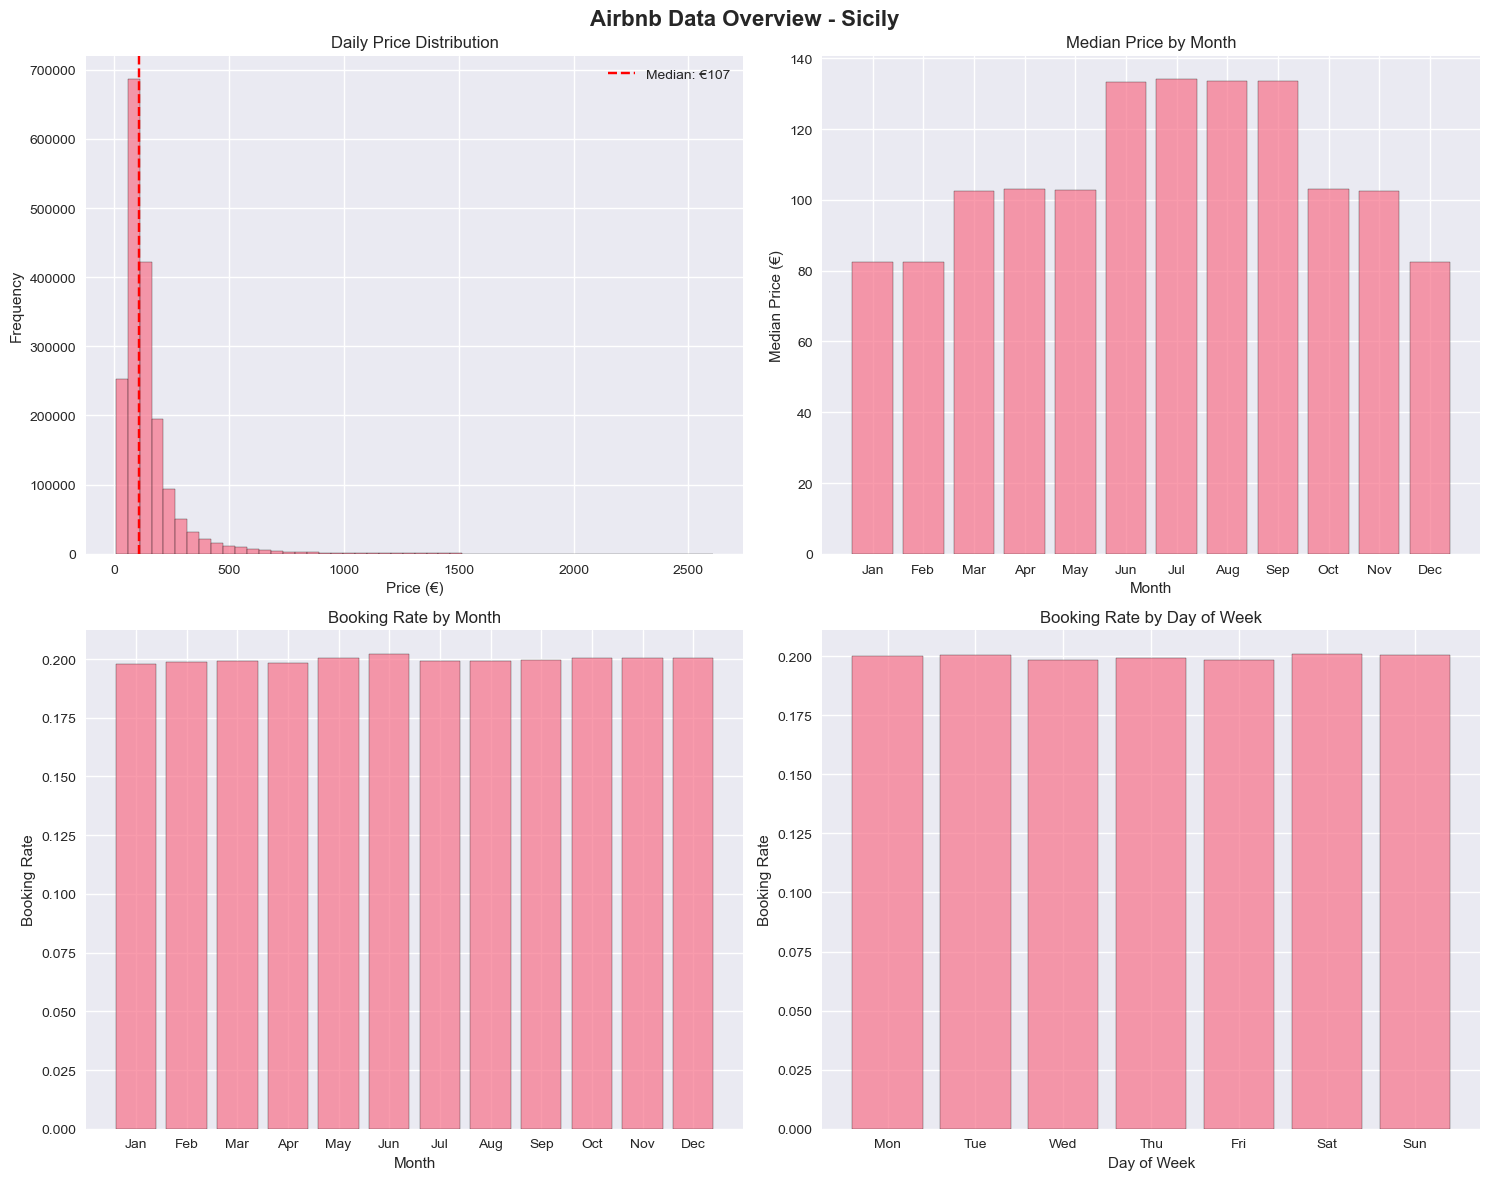

In [ ]:
# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Airbnb Data Overview - Sicily', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0, 0].hist(calendar_clean['price'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Daily Price Distribution')
axes[0, 0].set_xlabel('Price (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(calendar_clean['price'].median(), color='red', linestyle='--', 
                   label=f'Median: €{calendar_clean["price"].median():.0f}')
axes[0, 0].legend()

# 2. Price by month
calendar_clean['month'] = calendar_clean['date'].dt.month
monthly_prices = calendar_clean.groupby('month')['price'].median()
axes[0, 1].bar(monthly_prices.index, monthly_prices.values, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Median Price by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Median Price (€)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 3. Booking rate by month
monthly_bookings = calendar_clean.groupby('month')['booked'].mean()
axes[1, 0].bar(monthly_bookings.index, monthly_bookings.values, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Booking Rate by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Booking Rate')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 4. Booking rate by day of week
calendar_clean['day_of_week'] = calendar_clean['date'].dt.dayofweek
dow_bookings = calendar_clean.groupby('day_of_week')['booked'].mean()
axes[1, 1].bar(dow_bookings.index, dow_bookings.values, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Booking Rate by Day of Week')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Booking Rate')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()


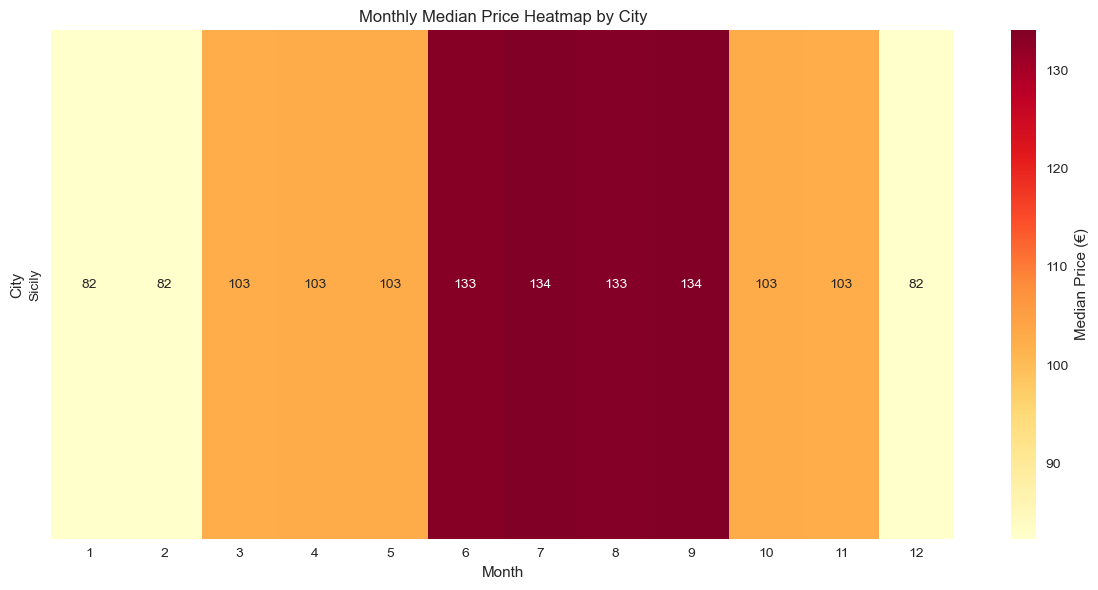

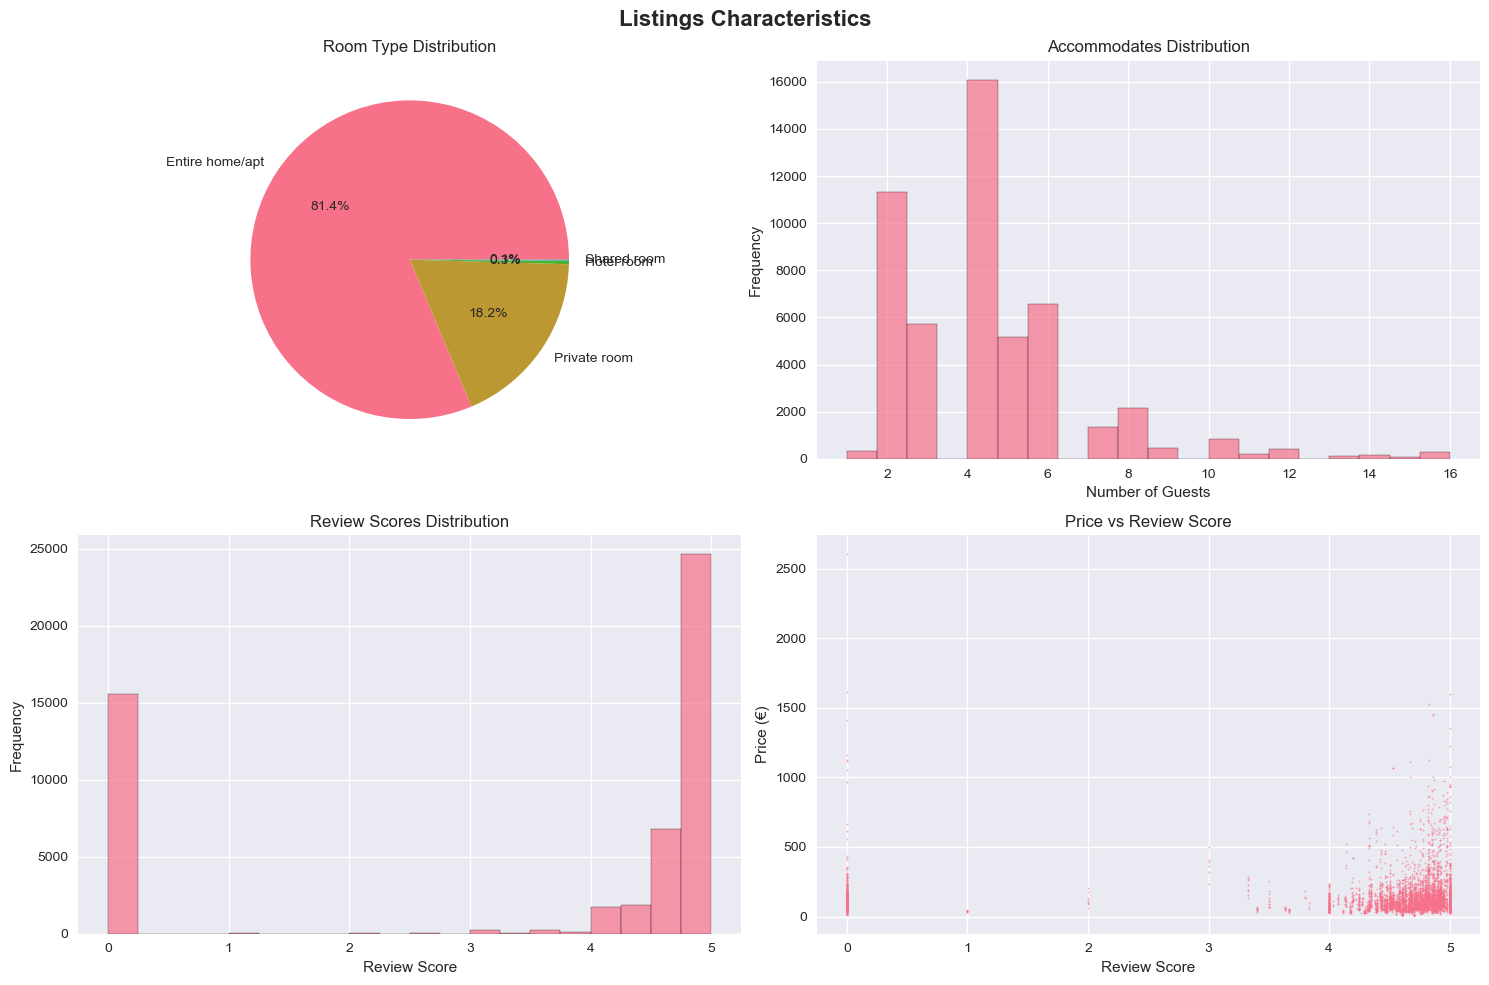

In [ ]:
# Monthly price heatmap
monthly_price_pivot = calendar_clean.pivot_table(
    values='price', 
    index='city', 
    columns='month', 
    aggfunc='median'
)

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_price_pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Median Price (€)'})
plt.title('Monthly Median Price Heatmap by City')
plt.xlabel('Month')
plt.ylabel('City')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'monthly_price_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Listings characteristics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Listings Characteristics', fontsize=16, fontweight='bold')

# Room type distribution
if 'room_type' in listings_clean.columns:
    room_type_counts = listings_clean['room_type'].value_counts()
    axes[0, 0].pie(room_type_counts.values, labels=room_type_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Room Type Distribution')

# Accommodates distribution
if 'accommodates' in listings_clean.columns:
    axes[0, 1].hist(listings_clean['accommodates'], bins=20, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Accommodates Distribution')
    axes[0, 1].set_xlabel('Number of Guests')
    axes[0, 1].set_ylabel('Frequency')

# Review scores distribution
if 'review_scores_rating' in listings_clean.columns:
    axes[1, 0].hist(listings_clean['review_scores_rating'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Review Scores Distribution')
    axes[1, 0].set_xlabel('Review Score')
    axes[1, 0].set_ylabel('Frequency')

# Price vs Review Score scatter
if 'review_scores_rating' in listings_clean.columns:
    # Sample for performance
    sample_size = min(5000, len(calendar_clean))
    sample_calendar = calendar_clean.sample(n=sample_size, random_state=42)
    
    # Merge with listings to get review scores
    merged_sample = sample_calendar.merge(
        listings_clean[['id', 'review_scores_rating']], 
        left_on='listing_id', 
        right_on='id', 
        how='left'
    )
    
    axes[1, 1].scatter(merged_sample['review_scores_rating'], merged_sample['price'], 
                      alpha=0.5, s=1)
    axes[1, 1].set_title('Price vs Review Score')
    axes[1, 1].set_xlabel('Review Score')
    axes[1, 1].set_ylabel('Price (€)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'listings_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()


## Save Cleaned Data


In [ ]:
# Save cleaned data as parquet files
print("Saving cleaned data...")

# Save listings
listings_clean.to_parquet(FEATURES_DIR / 'listings_clean.parquet', index=False)
print(f"✅ Saved listings_clean.parquet: {listings_clean.shape}")

# Save calendar
calendar_clean.to_parquet(FEATURES_DIR / 'calendar_clean.parquet', index=False)
print(f"✅ Saved calendar_clean.parquet: {calendar_clean.shape}")

# Data summary
print(f"\n📊 Data Summary:")
print(f"  Listings: {len(listings_clean)} properties")
print(f"  Calendar entries: {len(calendar_clean)} records")
print(f"  Date range: {calendar_clean['date'].min().strftime('%Y-%m-%d')} to {calendar_clean['date'].max().strftime('%Y-%m-%d')}")
print(f"  Cities: {sorted(calendar_clean['city'].unique())}")
print(f"  Average price: €{calendar_clean['price'].mean():.2f}")
print(f"  Booking rate: {calendar_clean['booked'].mean():.2%}")

print(f"\n✅ Data ingestion and EDA completed!")
print(f"📁 Files saved to: {FEATURES_DIR}")
print(f"📊 Plots saved to: {RESULTS_DIR}")


Saving cleaned data...
✅ Saved listings_clean.parquet: (51338, 16)
✅ Saved calendar_clean.parquet: (1827000, 9)

📊 Data Summary:
  Listings: 51338 properties
  Calendar entries: 1827000 records
  Date range: 2020-01-01 to 2024-12-31
  Cities: ['Sicily']
  Average price: €146.52
  Booking rate: 19.97%

✅ Data ingestion and EDA completed!
📁 Files saved to: /Users/antoniolavenia/Desktop/Data Science/features
📊 Plots saved to: /Users/antoniolavenia/Desktop/Data Science/results
